In [33]:
import pandas as pd
import numpy as np

In [34]:
df = pd.read_csv('weekly_model.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,YEAR,MONTH,WEEK,quantity,unit_price,fem,pol1,total_cost,DCM,gross_sales,avg_inventory_whp,avg_inventory_sales,product_cost_mxn,DCM_margin,qty_last_week,qty_avg_prev_4w
0,2023,1,1,10417.0,11007.037174,0.124674,0.062085,7528.909481,3478.127693,400179.430365,24.821671,34.004184,5219.796143,0.322315,NaN,NaN
1,2023,1,2,8675.0,10995.922703,0.123088,0.063457,7529.661724,3466.260979,341333.115069,18.079345,30.079167,5259.081003,0.322964,10417.0,10417.000000
2,2023,1,3,8215.0,10842.036452,0.123828,0.062285,7371.614555,3470.421897,331713.738355,21.820226,31.248927,5150.683951,0.324051,8675.0,9546.000000
3,2023,1,4,8756.0,10917.268312,0.118766,0.062900,7515.661302,3401.607010,363501.926577,19.458846,35.646789,5240.308749,0.320451,8215.0,9102.333333
4,2023,1,5,8435.0,10742.820781,0.121008,0.060095,7455.689425,3287.131357,319398.938096,19.953217,33.860169,5286.960042,0.313942,8756.0,9015.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,2025,6,27,8884.0,10550.124690,0.107175,0.061034,6956.809056,3593.315634,334280.511448,53.534415,0.046037,5005.101306,0.310274,10451.0,12042.000000
132,2025,7,28,8698.0,10781.784226,0.106052,0.062706,6940.100170,3841.684056,372813.521810,44.862173,0.048333,5011.762976,0.362616,8884.0,9722.250000
133,2025,7,29,10632.0,10673.595531,0.107239,0.058107,6854.340170,3819.255361,482886.063557,37.972296,0.041732,4902.372049,0.363747,8698.0,9348.250000
134,2025,7,30,9980.0,10843.339392,0.107178,0.060911,6959.165022,3884.174370,442001.229496,35.908905,0.044039,4955.927622,0.370448,10632.0,9666.250000


In [35]:
#lagging indicators
# 1-week lags
df['price_avg_last_week'] = df['unit_price'].shift(1)
df['cost_avg_last_week'] = df['total_cost'].shift(1)

# 4-week (prev) average of quantity (shifted so it uses only past info)
df['price_avg_prev_4w'] = (
    df['unit_price'].rolling(4, min_periods=1).mean().shift(1).reset_index(level=0, drop=True)
)
df['cost_avg_prev_4w'] = (
    df['total_cost'].rolling(4, min_periods=1).mean().shift(1).reset_index(level=0, drop=True)
)

#special weeks
df['event_effect'] = 0  # default: no event
df.loc[df['WEEK'].isin([45, 46]), 'event_effect'] = 10 #buen fin
df.loc[df['WEEK'].isin([18, 19, 49, 50, 51]), 'event_effect'] = 1 
df.loc[df['WEEK'].isin([1, 2, 3, 4, 5, 6]), 'event_effect'] = -5  # Holiday dip


df

,YEAR,MONTH,WEEK,quantity,unit_price,fem,pol1,total_cost,DCM,gross_sales,...,avg_inventory_sales,product_cost_mxn,DCM_margin,qty_last_week,qty_avg_prev_4w,price_avg_last_week,cost_avg_last_week,price_avg_prev_4w,cost_avg_prev_4w,event_effect
0,2023,1,1,10417.0,11007.037174,0.124674,0.062085,7528.909481,3478.127693,400179.430365,...,34.004184,5219.796143,0.322315,NaN,NaN,NaN,NaN,NaN,NaN,-5
1,2023,1,2,8675.0,10995.922703,0.123088,0.063457,7529.661724,3466.260979,341333.115069,...,30.079167,5259.081003,0.322964,10417.0,10417.000000,11007.037174,7528.909481,11007.037174,7528.909481,-5
2,2023,1,3,8215.0,10842.036452,0.123828,0.062285,7371.614555,3470.421897,331713.738355,...,31.248927,5150.683951,0.324051,8675.0,9546.000000,10995.922703,7529.661724,11001.479938,7529.285602,-5
3,2023,1,4,8756.0,10917.268312,0.118766,0.062900,7515.661302,3401.607010,363501.926577,...,35.646789,5240.308749,0.320451,8215.0,9102.333333,10842.036452,7371.614555,10948.332110,7476.728587,-5
4,2023,1,5,8435.0,10742.820781,0.121008,0.060095,7455.689425,3287.131357,319398.938096,...,33.860169,5286.960042,0.313942,8756.0,9015.750000,10917.268312,7515.661302,10940.566160,7486.461766,-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,2025,6,27,8884.0,10550.124690,0.107175,0.061034,6956.809056,3593.315634,334280.511448,...,0.046037,5005.101306,0.310274,10451.0,12042.000000,10769.473387,7093.095306,10539.318711,6905.286279,0
132,2025,7,28,8698.0,10781.784226,0.106052,0.062706,6940.100170,3841.684056,372813.521810,...,0.048333,5011.762976,0.362616,8884.0,9722.250000,10550.124690,6956.809056,10590.177194,6939.515441,0
133,2025,7,29,10632.0,10673.595531,0.107239,0.058107,6854.340170,3819.255361,482886.063557,...,0.041732,4902.372049,0.363747,8698.0,9348.250000,10781.784226,6940.100170,10699.740074,6961.517278,0
134,2025,7,30,9980.0,10843.339392,0.107178,0.060911,6959.165022,3884.174370,442001.229496,...,0.044039,4955.927622,0.370448,10632.0,9666.250000,10673.595531,6854.340170,10693.744459,6961.086175,0


In [36]:
df_full = pd.read_csv('final_database.csv')
df_full = df_full.drop(columns=['Unnamed: 0'])
df_full

,TP,SKU,WEEK,MONTH,YEAR,Manuf_name,segment,Segmento_Whp,fem,pol1,product_cost_mxn,unit_price,total_cost,quantity,gross_sales,avg_inventory_whp,avg_inventory_sales,DCM,DCM_margin
0,CHEDRAUI,7MWET4027HW,1,1,2024,WHIRLPOOL,LAUNDRY CENTER,145. STACKED LAUNDRY CENTER,0.125,0.1300,10044.575406,11377.135000,14302.171081,2.0,22754.270000,0.50,0.0,-2925.036081,-0.257098
1,CHEDRAUI,7MWET4027HW,1,12,2024,WHIRLPOOL,LAUNDRY CENTER,145. STACKED LAUNDRY CENTER,0.125,0.1300,10044.575406,14600.507292,15124.131015,12.0,145247.800000,2.25,0.0,-523.623723,-0.184944
2,CHEDRAUI,7MWET4027HW,2,1,2023,WHIRLPOOL,LAUNDRY CENTER,145. STACKED LAUNDRY CENTER,0.125,0.1300,11101.899132,21547.400000,18095.694093,1.0,21547.400000,1.00,0.0,3451.705907,0.160191
3,CHEDRAUI,7MWET4027HW,2,1,2025,WHIRLPOOL,LAUNDRY CENTER,145. STACKED LAUNDRY CENTER,0.125,0.1300,10573.237269,15927.995000,16062.693099,0.0,-13652.650000,0.00,0.0,-134.698099,-0.177987
4,CHEDRAUI,7MWET4027HW,3,1,2024,WHIRLPOOL,LAUNDRY CENTER,145. STACKED LAUNDRY CENTER,0.125,0.1300,10044.575406,13273.270000,14785.685506,1.0,13273.270000,0.00,0.0,-1512.415506,-0.113944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30841,WALMART,WW21BTAHME,49,12,2024,WHIRLPOOL,TOP LOAD,095. TL IMPELLER 20-24 KG,0.150,0.2079,4885.090000,9705.992287,6131.870000,10.0,115277.769972,0.00,0.0,3574.122287,0.368239
30842,WALMART,WW21BTAHME,50,12,2023,WHIRLPOOL,TOP LOAD,095. TL IMPELLER 20-24 KG,0.150,0.2079,5399.310000,10422.410000,10507.510539,1.0,10422.410000,0.00,0.0,-85.100539,-0.008165
30843,WALMART,WW21BTAHME,50,12,2024,WHIRLPOOL,TOP LOAD,095. TL IMPELLER 20-24 KG,0.150,0.2079,4885.090000,9705.992287,6131.870000,3.0,34366.288294,0.00,0.0,3574.122287,0.368239
30844,WALMART,WW21BTAHME,51,12,2023,WHIRLPOOL,TOP LOAD,095. TL IMPELLER 20-24 KG,0.150,0.2079,5399.310000,12922.410000,11402.260539,1.0,12922.410000,0.00,0.0,1520.149461,0.117637


In [37]:
df_tp_segment = df_full.groupby(['TP', 'segment'], as_index=False).agg(quantity=('quantity', 'sum'))
df_tp_segment

,TP,segment,quantity
0,CHEDRAUI,FRONT LOAD,2143.0
1,CHEDRAUI,LAUNDRY CENTER,330.0
2,CHEDRAUI,SINGLE TUB,1251.0
3,CHEDRAUI,TOP LOAD,37995.0
4,CHEDRAUI,TWIN TUB,11212.0
5,CHEDRAUI,WASHER-DRYER,305.0
6,COPPEL,FRONT LOAD,9192.0
7,COPPEL,LAUNDRY CENTER,110.0
8,COPPEL,SINGLE TUB,116237.0
9,COPPEL,TOP LOAD,224321.0


In [38]:
df_sum = df_tp_segment.groupby(['TP'], as_index=False).agg(quantity=('quantity', 'sum'))
total_quantity = df_sum['quantity'].sum()
last_row = {
    'TP': 'Total',
    'quantity': total_quantity
}

df_sum = pd.concat([df_sum, pd.DataFrame([last_row])], ignore_index=True)
total = df_sum.iloc[-1]['quantity'] #the last one is the total
df_sum['%'] = (df_sum['quantity'] / total)

df_sum


,TP,quantity,%
0,CHEDRAUI,53236.0,0.037783
1,COPPEL,354011.0,0.251248
2,D2C,197351.0,0.140064
3,ELEKTRA,217840.0,0.154605
4,HOME DEPOT,100101.0,0.071044
5,LIVERPOOL,211479.0,0.150091
6,PALACIO DE HIERRO,15745.0,0.011175
7,SEARS,49956.0,0.035455
8,WALMART,209290.0,0.148537
9,Total,1409009.0,1.000000


In [39]:
segment_percent = {}

for tp, group in df_tp_segment.groupby('TP'):
    # sum quantity per segment for this TP
    df_sum1 = (
        group.groupby('segment', as_index=False)['quantity']
        .sum()
        .sort_values('quantity', ascending=False)
    )

    #total quantity for this TP
    total_quantity = df_sum1['quantity'].sum()
    df_sum1['%'] = (df_sum1['quantity'] / total_quantity)

    #total row
    total_row = pd.DataFrame({
        'segment': ['Total'],
        'quantity': [total_quantity],
        '%': [1]
    })

    df_sum1 = pd.concat([df_sum1, total_row], ignore_index=True)
    segment_percent[tp] = df_sum1

    
segment_percent['CHEDRAUI']
        

,segment,quantity,%
0,TOP LOAD,37995.0,0.713709
1,TWIN TUB,11212.0,0.210609
2,FRONT LOAD,2143.0,0.040255
3,SINGLE TUB,1251.0,0.023499
4,LAUNDRY CENTER,330.0,0.006199
5,WASHER-DRYER,305.0,0.005729
6,Total,53236.0,1.000000


In [40]:
df_segment = df_full.groupby(['WEEK', 'MONTH', 'YEAR', 'segment'], as_index=False).agg(unit_price=('unit_price', 'mean'), total_cost=('total_cost', 'mean'),
                            quantity=('quantity', 'sum'), avg_inventory_whp=('avg_inventory_whp', 'mean'), DCM=('DCM', 'mean'), 
                            DCM_margin=('DCM_margin', 'mean'))

df_segment

,WEEK,MONTH,YEAR,segment,unit_price,total_cost,quantity,avg_inventory_whp,DCM,DCM_margin
0,1,1,2023,FRONT LOAD,12164.374177,8543.459091,557.0,9.015177,3620.915086,0.291120
1,1,1,2023,LAUNDRY CENTER,21050.511291,16747.506370,77.0,8.466667,4303.004921,0.193320
2,1,1,2023,SINGLE TUB,4181.653138,2280.509047,1457.0,9.291667,1901.144091,0.453878
3,1,1,2023,TOP LOAD,10887.995154,7176.262865,7936.0,38.999939,3711.732289,0.329450
4,1,1,2023,TWIN TUB,5437.338830,3362.288857,374.0,22.244048,2075.049972,0.367367
...,...,...,...,...,...,...,...,...,...,...
810,52,12,2024,LAUNDRY CENTER,18667.416293,13985.193979,249.0,0.000000,4682.222314,0.213412
811,52,12,2024,SINGLE TUB,4216.013893,2186.431436,1532.0,0.165738,2029.582456,0.484277
812,52,12,2024,TOP LOAD,10243.892923,6138.249280,8715.0,0.394469,4105.643643,0.398513
813,52,12,2024,TWIN TUB,5205.734119,2886.008363,934.0,0.054762,2319.725756,0.436693


In [41]:
competitors = pd.read_csv('competitors.csv')
competitors = competitors.drop(columns=['Unnamed: 0'])
competitors = competitors.rename(columns={'segment_y': 'segment'})
competitors

,WEEK,YEAR,segment,SKU,unit_price
0,1,2023,FRONT LOAD,DF20WV2R,25009.000000
1,1,2023,FRONT LOAD,DF20WV2R (PEDESTAL),31999.000000
2,1,2023,FRONT LOAD,DF20WV2W,15799.000000
3,1,2023,FRONT LOAD,DF22BV2SR (PEDESTAL),41299.000000
4,1,2023,FRONT LOAD,DF22VV2SR (PEDESTAL),26999.000000
...,...,...,...,...,...
50729,52,2024,WASHER-DRYER,WD26DVS15R7,68999.000000
50730,52,2024,WASHER-DRYER,WD5Q1542BB,22899.000000
50731,52,2024,WASHER-DRYER,WD5S1645BT,15343.969727
50732,52,2024,WASHER-DRYER,WDQY1514,17284.714286


In [42]:
competitors_df = competitors.groupby(['WEEK', 'YEAR', 'segment'], as_index=False).agg(unit_price=('unit_price', 'mean'))
competitors_df = competitors_df.rename(columns={'unit_price': 'competitor_price'})
competitors_df                                                                                         

,WEEK,YEAR,segment,competitor_price
0,1,2023,FRONT LOAD,25295.037886
1,1,2023,LAUNDRY CENTER,39408.939867
2,1,2023,SINGLE TUB,4841.715583
3,1,2023,TOP LOAD,17460.092096
4,1,2023,TWIN TUB,8075.528579
...,...,...,...,...
1074,52,2024,TOP LOAD,18555.502141
1075,52,2024,TWIN TUB,7758.918915
1076,52,2024,TWINWASH MINI,24999.000000
1077,52,2024,WASH TOWER,64758.473821


In [43]:
df_merged = df_segment.merge(
    competitors_df[['WEEK', 'YEAR', 'segment', 'competitor_price']],
    on=['WEEK', 'YEAR', 'segment'],
    how='left'
)
df_merged

,WEEK,MONTH,YEAR,segment,unit_price,total_cost,quantity,avg_inventory_whp,DCM,DCM_margin,competitor_price
0,1,1,2023,FRONT LOAD,12164.374177,8543.459091,557.0,9.015177,3620.915086,0.291120,25295.037886
1,1,1,2023,LAUNDRY CENTER,21050.511291,16747.506370,77.0,8.466667,4303.004921,0.193320,39408.939867
2,1,1,2023,SINGLE TUB,4181.653138,2280.509047,1457.0,9.291667,1901.144091,0.453878,4841.715583
3,1,1,2023,TOP LOAD,10887.995154,7176.262865,7936.0,38.999939,3711.732289,0.329450,17460.092096
4,1,1,2023,TWIN TUB,5437.338830,3362.288857,374.0,22.244048,2075.049972,0.367367,8075.528579
...,...,...,...,...,...,...,...,...,...,...,...
810,52,12,2024,LAUNDRY CENTER,18667.416293,13985.193979,249.0,0.000000,4682.222314,0.213412,37206.150942
811,52,12,2024,SINGLE TUB,4216.013893,2186.431436,1532.0,0.165738,2029.582456,0.484277,5025.040044
812,52,12,2024,TOP LOAD,10243.892923,6138.249280,8715.0,0.394469,4105.643643,0.398513,18555.502141
813,52,12,2024,TWIN TUB,5205.734119,2886.008363,934.0,0.054762,2319.725756,0.436693,7758.918915


In [44]:
#lagging indicators
# 1-week lags
df_merged['qty_last_week']   = df_merged.groupby('segment')['quantity'].shift(1)
df_merged['price_last_week'] = df_merged.groupby('segment')['unit_price'].shift(1)
df_merged['comp_last_week']  = df_merged.groupby('segment')['competitor_price'].shift(1)

# 4-week (prev) average of quantity (shifted so it uses only past info)
df_merged['qty_avg_prev_4w'] = (
    df_merged
      .groupby('segment')['quantity']
      .rolling(4, min_periods=1).mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df_merged

,WEEK,MONTH,YEAR,segment,unit_price,total_cost,quantity,avg_inventory_whp,DCM,DCM_margin,competitor_price,qty_last_week,price_last_week,comp_last_week,qty_avg_prev_4w
0,1,1,2023,FRONT LOAD,12164.374177,8543.459091,557.0,9.015177,3620.915086,0.291120,25295.037886,NaN,NaN,NaN,NaN
1,1,1,2023,LAUNDRY CENTER,21050.511291,16747.506370,77.0,8.466667,4303.004921,0.193320,39408.939867,NaN,NaN,NaN,814.75
2,1,1,2023,SINGLE TUB,4181.653138,2280.509047,1457.0,9.291667,1901.144091,0.453878,4841.715583,NaN,NaN,NaN,136.00
3,1,1,2023,TOP LOAD,10887.995154,7176.262865,7936.0,38.999939,3711.732289,0.329450,17460.092096,NaN,NaN,NaN,1888.50
4,1,1,2023,TWIN TUB,5437.338830,3362.288857,374.0,22.244048,2075.049972,0.367367,8075.528579,NaN,NaN,NaN,9045.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,52,12,2024,LAUNDRY CENTER,18667.416293,13985.193979,249.0,0.000000,4682.222314,0.213412,37206.150942,83.0,19848.139402,37019.999811,88.00
811,52,12,2024,SINGLE TUB,4216.013893,2186.431436,1532.0,0.165738,2029.582456,0.484277,5025.040044,2134.0,4095.997803,4961.054551,1827.50
812,52,12,2024,TOP LOAD,10243.892923,6138.249280,8715.0,0.394469,4105.643643,0.398513,18555.502141,8410.0,10276.792935,19535.210044,9013.75
813,52,12,2024,TWIN TUB,5205.734119,2886.008363,934.0,0.054762,2319.725756,0.436693,7758.918915,635.0,5386.322098,7629.676731,877.50


# XGBRegressor

In [45]:
# parse year/week into a datetime column
df['date'] = pd.to_datetime(
    df['YEAR'].astype(str) + df['WEEK'].astype(str) + '1',
    format='%G%V%u'
)

# drop NaNs from initial lag features
df = df.dropna(subset=['qty_last_week', 'qty_avg_prev_4w'])

df['week_sin'] = np.sin(2 * np.pi * df['WEEK'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['WEEK'] / 52)

df

C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\9422759.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['week_sin'] = np.sin(2 * np.pi * df['WEEK'] / 52)
C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\9422759.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['week_cos'] = np.cos(2 * np.pi * df['WEEK'] / 52)


,YEAR,MONTH,WEEK,quantity,unit_price,fem,pol1,total_cost,DCM,gross_sales,...,qty_last_week,qty_avg_prev_4w,price_avg_last_week,cost_avg_last_week,price_avg_prev_4w,cost_avg_prev_4w,event_effect,date,week_sin,week_cos
1,2023,1,2,8675.0,10995.922703,0.123088,0.063457,7529.661724,3466.260979,341333.115069,...,10417.0,10417.000000,11007.037174,7528.909481,11007.037174,7528.909481,-5,2023-01-09,0.239316,0.970942
2,2023,1,3,8215.0,10842.036452,0.123828,0.062285,7371.614555,3470.421897,331713.738355,...,8675.0,9546.000000,10995.922703,7529.661724,11001.479938,7529.285602,-5,2023-01-16,0.354605,0.935016
3,2023,1,4,8756.0,10917.268312,0.118766,0.062900,7515.661302,3401.607010,363501.926577,...,8215.0,9102.333333,10842.036452,7371.614555,10948.332110,7476.728587,-5,2023-01-23,0.464723,0.885456
4,2023,1,5,8435.0,10742.820781,0.121008,0.060095,7455.689425,3287.131357,319398.938096,...,8756.0,9015.750000,10917.268312,7515.661302,10940.566160,7486.461766,-5,2023-01-30,0.568065,0.822984
5,2023,2,6,6632.0,10995.724224,0.125527,0.065198,7501.296480,3494.427744,268471.105881,...,8435.0,8520.250000,10742.820781,7455.689425,10874.512062,7468.156751,-5,2023-02-06,0.663123,0.748511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,2025,6,27,8884.0,10550.124690,0.107175,0.061034,6956.809056,3593.315634,334280.511448,...,10451.0,12042.000000,10769.473387,7093.095306,10539.318711,6905.286279,0,2025-06-30,-0.120537,-0.992709
132,2025,7,28,8698.0,10781.784226,0.106052,0.062706,6940.100170,3841.684056,372813.521810,...,8884.0,9722.250000,10550.124690,6956.809056,10590.177194,6939.515441,0,2025-07-07,-0.239316,-0.970942
133,2025,7,29,10632.0,10673.595531,0.107239,0.058107,6854.340170,3819.255361,482886.063557,...,8698.0,9348.250000,10781.784226,6940.100170,10699.740074,6961.517278,0,2025-07-14,-0.354605,-0.935016
134,2025,7,30,9980.0,10843.339392,0.107178,0.060911,6959.165022,3884.174370,442001.229496,...,10632.0,9666.250000,10673.595531,6854.340170,10693.744459,6961.086175,0,2025-07-21,-0.464723,-0.885456


In [46]:
features = [
    'week_sin', 'week_cos', 'price_avg_last_week', 'qty_last_week', 'qty_avg_prev_4w', 'event_effect'
]
target = 'quantity'

X = df[features]
y = df[target]


In [47]:
train_size = int(len(df) * 0.7) #70% for training

# for time series forecasting we have to mantain time order

#first 70%
X_train = df[features].iloc[:train_size]
y_train = df[target].iloc[:train_size]

#last 30%
X_test = df[features].iloc[train_size:]
y_test = df[target].iloc[train_size:]

date_test = df['date'].iloc[train_size:]

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# XGBRegressor is a machine learning model that builds an ensemble (a team) of many small decision trees, each one correcting the mistakes of the previous ones

model = XGBRegressor(
    n_estimators=500, #number of trees, more = better accuracy but slower
    learning_rate=0.05, #step size, smaller = smoother but slower
    max_depth=5, #number of splits (levels), smaller = simpler
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42 
)

#train the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#evaluation
mae = mean_absolute_error(y_test, y_pred) #average absolute difference between predicted and actual
r2 = r2_score(y_test, y_pred) #how much of the variance is explained
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}") 
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.3f}%") 

MAE: 2530.975
R2: 0.611
RMSE: 4727.141
MAPE: 19.039%


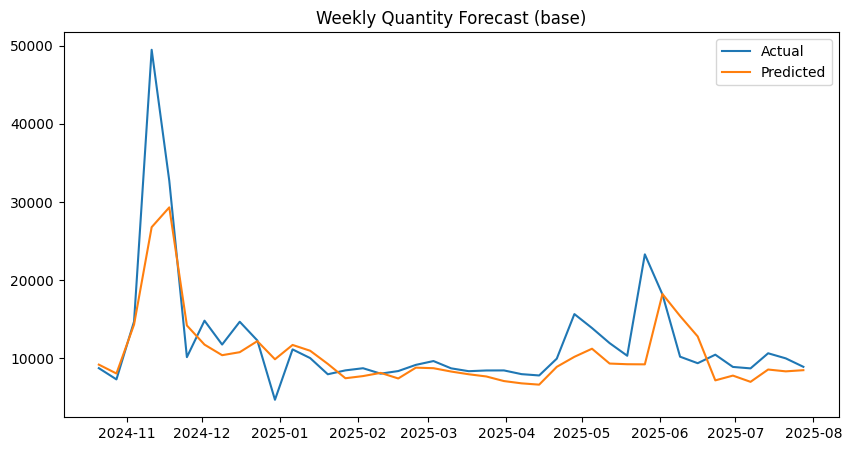

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(date_test, y_test, label='Actual')
plt.plot(date_test, y_pred, label='Predicted')
plt.legend()
plt.title("Weekly Quantity Forecast (base)")
plt.show()

In [49]:
from sklearn.model_selection import GridSearchCV

# Define your base model
xgb = XGBRegressor(
    objective='reg:squarederror',  # standard for regression
    random_state=42,
    n_jobs=-1                      # use all cores
)

# Define hyperparameter grid
param_grid = {
    #boosting parameters
    'n_estimators': [100, 300, 500, 800, 1000],
    'learning_rate': [0.01, 0.05, .1, .15, .2, .25, .3],
    #tree parameters
    'max_depth': [3, 5, 7, 10],
    #sample parameters
    'subsample': [.5, .7, 1],
    'colsample_bytree': [.5, .7, 1]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit
grid_search.fit(X_train, y_train)

# Show best results
print("Best parameters:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)

Fitting 3 folds for each of 1260 candidates, totalling 3780 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.5}
Best RMSE: -0.21764205965309102


In [50]:
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred) #average absolute difference between predicted and actual
r2 = r2_score(y_test, y_pred) #how much of the variance is explained
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}") 
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.3f}%") 

MAE: 2443.156
R2: 0.736
RMSE: 3892.857
MAPE: 19.498%


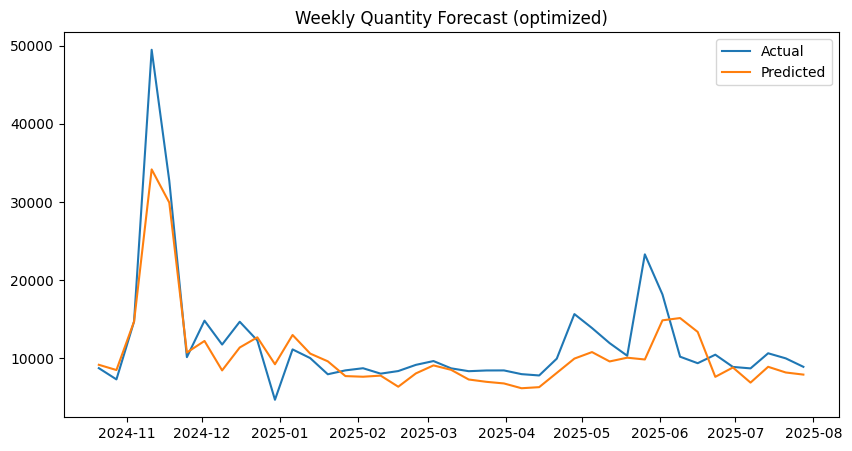

In [51]:
plt.figure(figsize=(10,5))
plt.plot(date_test, y_test, label='Actual')
plt.plot(date_test, y_pred, label='Predicted')
plt.legend()
plt.title("Weekly Quantity Forecast (optimized)")
plt.show()

# Shap

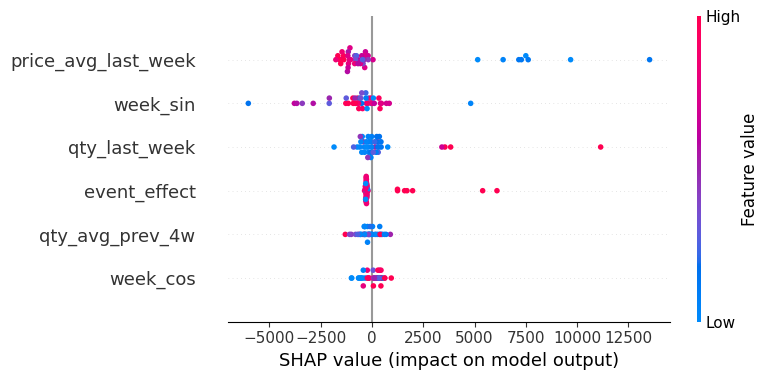

In [52]:
import shap

explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

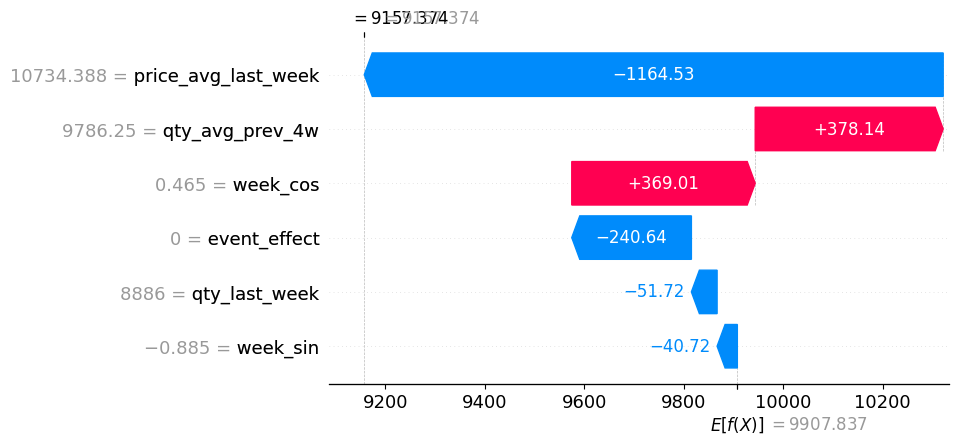

In [53]:
shap.plots.waterfall(shap_values[0])

# prediction

In [54]:
segment_percent['LIVERPOOL'].loc[segment_percent['LIVERPOOL']['segment'] == 'TOP LOAD', '%']

0    0.646646
Name: %, dtype: float64

In [55]:
def predict_quantity(week_number, tp, segment, price_last_week, qty_last_week, qty_avg_prev_4w):
    week_sin = np.sin(2 * np.pi * week_number / 52) 
    week_cos = np.cos(2 * np.pi * week_number / 52)
    event_effect = df.loc[df['WEEK'] == week_number, 'event_effect'].iloc[0]
    x = np.array([[week_sin, week_cos, price_last_week, qty_last_week, qty_avg_prev_4w, event_effect]])
    y_hat = float(best_xgb.predict(x))
    
    quantity_tp = float(y_hat * df_sum.loc[df_sum['TP'] == tp, '%'].iloc[0])
    quantity_tp_segment = float(quantity_tp * segment_percent[tp].loc[segment_percent[tp]['segment'] == segment, '%'])
    
    result = pd.DataFrame([{
        'week_number': week_number,
        'tp': tp,
        'segment': segment,
        'price_last_week': price_last_week,
        'qty_last_week': qty_last_week,
        'qty_avg_prev_4w': qty_avg_prev_4w,
        'Overall quantity': y_hat,
        f'Quantity for {tp}': quantity_tp,
        f'Quantity for {tp} for {segment}': quantity_tp_segment
    }])

    return result

In [56]:
# During Buen Fin
prediction = predict_quantity(45, 'LIVERPOOL', 'TOP LOAD', 5000, 5000, 3000)
prediction

C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\2483647852.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat = float(best_xgb.predict(x))
C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\2483647852.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  quantity_tp_segment = float(quantity_tp * segment_percent[tp].loc[segment_percent[tp]['segment'] == segment, '%'])


,week_number,tp,segment,price_last_week,qty_last_week,qty_avg_prev_4w,Overall quantity,Quantity for LIVERPOOL,Quantity for LIVERPOOL for TOP LOAD
0,45,LIVERPOOL,TOP LOAD,5000,5000,3000,32762.523438,4917.346656,3179.781396


In [57]:
# During Dia de las madres
prediction = predict_quantity(18, 'ELEKTRA', 'SINGLE TUB', 3000, 3000, 6500)
prediction

C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\2483647852.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat = float(best_xgb.predict(x))
C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\2483647852.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  quantity_tp_segment = float(quantity_tp * segment_percent[tp].loc[segment_percent[tp]['segment'] == segment, '%'])


,week_number,tp,segment,price_last_week,qty_last_week,qty_avg_prev_4w,Overall quantity,Quantity for ELEKTRA,Quantity for ELEKTRA for SINGLE TUB
0,18,ELEKTRA,SINGLE TUB,3000,3000,6500,17304.539062,2675.37027,703.733896


In [58]:
# During second week of the year (low demand)
prediction = predict_quantity(2, 'COPPEL', 'SINGLE TUB', 15000, 800, 1200)
prediction

C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\2483647852.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hat = float(best_xgb.predict(x))
C:\Users\Ramon\AppData\Local\Temp\ipykernel_12388\2483647852.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  quantity_tp_segment = float(quantity_tp * segment_percent[tp].loc[segment_percent[tp]['segment'] == segment, '%'])


,week_number,tp,segment,price_last_week,qty_last_week,qty_avg_prev_4w,Overall quantity,Quantity for COPPEL,Quantity for COPPEL for SINGLE TUB
0,2,COPPEL,SINGLE TUB,15000,800,1200,5775.42041,1451.064085,476.446596


# prophet

In [59]:
from prophet import Prophet

df_work = df.copy()

# Ensure datetime and sort
df_work['date'] = pd.to_datetime(df_work['date'])
df_work = df_work.sort_values('date').reset_index(drop=True)

# rename for Prophet
df_work = df_work.rename(columns={'date': 'ds', 'quantity': 'y'})

df_work.head()


,YEAR,MONTH,WEEK,y,unit_price,fem,pol1,total_cost,DCM,gross_sales,...,qty_last_week,qty_avg_prev_4w,price_avg_last_week,cost_avg_last_week,price_avg_prev_4w,cost_avg_prev_4w,event_effect,ds,week_sin,week_cos
0,2023,1,2,8675.0,10995.922703,0.123088,0.063457,7529.661724,3466.260979,341333.115069,...,10417.0,10417.000000,11007.037174,7528.909481,11007.037174,7528.909481,-5,2023-01-09,0.239316,0.970942
1,2023,1,3,8215.0,10842.036452,0.123828,0.062285,7371.614555,3470.421897,331713.738355,...,8675.0,9546.000000,10995.922703,7529.661724,11001.479938,7529.285602,-5,2023-01-16,0.354605,0.935016
2,2023,1,4,8756.0,10917.268312,0.118766,0.062900,7515.661302,3401.607010,363501.926577,...,8215.0,9102.333333,10842.036452,7371.614555,10948.332110,7476.728587,-5,2023-01-23,0.464723,0.885456
3,2023,1,5,8435.0,10742.820781,0.121008,0.060095,7455.689425,3287.131357,319398.938096,...,8756.0,9015.750000,10917.268312,7515.661302,10940.566160,7486.461766,-5,2023-01-30,0.568065,0.822984
4,2023,2,6,6632.0,10995.724224,0.125527,0.065198,7501.296480,3494.427744,268471.105881,...,8435.0,8520.250000,10742.820781,7455.689425,10874.512062,7468.156751,-5,2023-02-06,0.663123,0.748511


In [60]:
train_size = int(len(df_work) * 0.7)
train_df = df_work.iloc[:train_size].copy()
test_df  = df_work.iloc[train_size:].copy()

train_df.tail(3), test_df.head(3)


(    YEAR  MONTH  WEEK        y    unit_price       fem      pol1   total_cost  \
 91  2024      9    40  13775.0  10569.542496  0.114496  0.067965  6835.825313   
 92  2024     10    41   7834.0  10735.634196  0.114927  0.067370  6953.897750   
 93  2024     10    42   8886.0  10734.387789  0.113652  0.065024  6769.249846   
 
             DCM    gross_sales  ...  qty_last_week  qty_avg_prev_4w  \
 91  3733.717183  590024.520069  ...         8650.0          8624.25   
 92  3781.736446  339211.152844  ...        13775.0          9964.75   
 93  3965.137943  394648.201997  ...         7834.0          9895.25   
 
     price_avg_last_week  cost_avg_last_week  price_avg_prev_4w  \
 91         10618.103395         6881.860673       10734.435500   
 92         10569.542496         6835.825313       10698.796688   
 93         10735.634196         6953.897750       10717.352644   
 
     cost_avg_prev_4w  event_effect         ds  week_sin  week_cos  
 91       6898.193160             0 2024-

In [61]:
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05  # higher -> more flexible trend
)

# exogenous regressors
for reg in ['price_avg_last_week', 'qty_last_week', 'qty_avg_prev_4w', 'event_effect']:
    m.add_regressor(reg)

# fit on training window only
m.fit(train_df[['ds','y','price_avg_last_week', 'qty_last_week', 'qty_avg_prev_4w', 'event_effect']])


10:13:41 - cmdstanpy - INFO - Chain [1] start processing
10:13:42 - cmdstanpy - INFO - Chain [1] done processing


In [62]:
# Build future exactly from your existing rows (TRAIN + TEST dates)
future = df_work[['ds','price_avg_last_week', 'qty_last_week', 'qty_avg_prev_4w', 'event_effect']].copy()

# Sanity check: no NaNs in required columns
assert not future[['price_avg_last_week', 'qty_last_week', 'qty_avg_prev_4w', 'event_effect']].isna().any().any(), \
       "Still have NaNs in regressors — check your source data."

# Predict
forecast = m.predict(future)

# Evaluate on TEST dates only (same as before)
pred_test = (forecast[forecast['ds'].isin(test_df['ds'])]
             [['ds','yhat','yhat_lower','yhat_upper']]
             .merge(test_df[['ds','y']], on='ds', how='left')
             .sort_values('ds'))



In [63]:
forecast = m.predict(future)

# Keep only TEST dates
pred_test = forecast[forecast['ds'].isin(test_df['ds'])][['ds','yhat','yhat_lower','yhat_upper']].merge(
    test_df[['ds','y']], on='ds', how='left'
).sort_values('ds')

# Metrics
y_true = pred_test['y']
y_pred = pred_test['yhat']

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2   = r2_score(y_true, y_pred)

print("Prophet + Regressors (TEST)")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.3f}")

pred_test.tail(10)



Prophet + Regressors (TEST)
MAE: 4059.915
RMSE: 5279.289
MAPE: 36.76%
R2: 0.515


,ds,yhat,yhat_lower,yhat_upper,y
31,2025-05-26,12650.610195,9407.281781,15893.733971,23297.0
32,2025-06-02,12629.971827,9424.510420,15868.707201,18163.0
33,2025-06-09,9032.991998,5634.078516,12237.092684,10194.0
34,2025-06-16,7192.237407,4024.153491,10189.387041,9360.0
35,2025-06-23,3563.982731,409.476608,6586.643787,10451.0
36,2025-06-30,6017.538073,2687.326857,9360.671848,8884.0
37,2025-07-07,10042.090374,6641.466143,13205.605808,8698.0
38,2025-07-14,8924.346934,5657.143998,11958.219413,10632.0
39,2025-07-21,9412.853716,6319.833773,12481.192523,9980.0
40,2025-07-28,7774.356260,4823.677490,11139.883187,8898.0


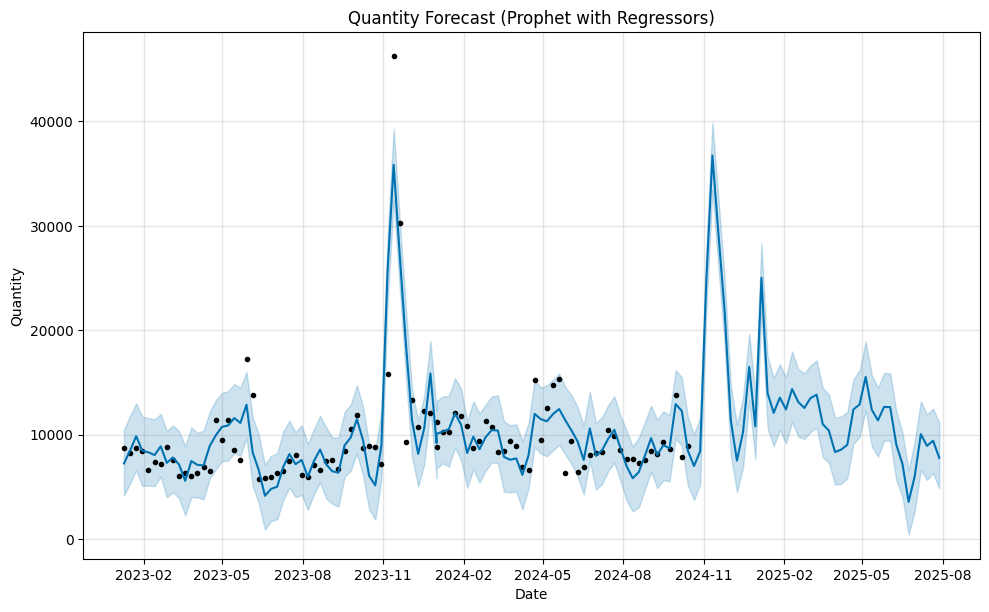

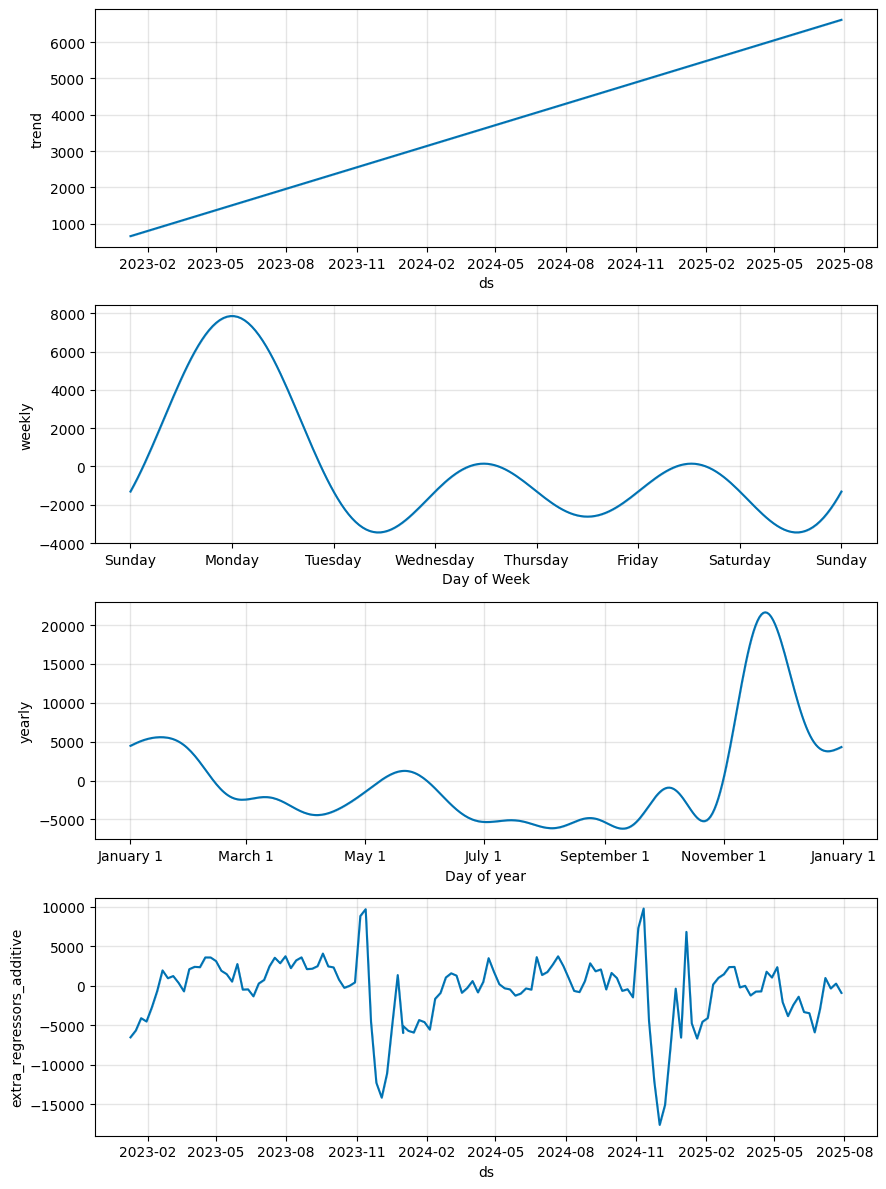

In [64]:
# Full horizon forecast plot
m.plot(forecast)
plt.title('Quantity Forecast (Prophet with Regressors)')
plt.xlabel('Date'); plt.ylabel('Quantity')
plt.show()

m.plot_components(forecast)
plt.show()


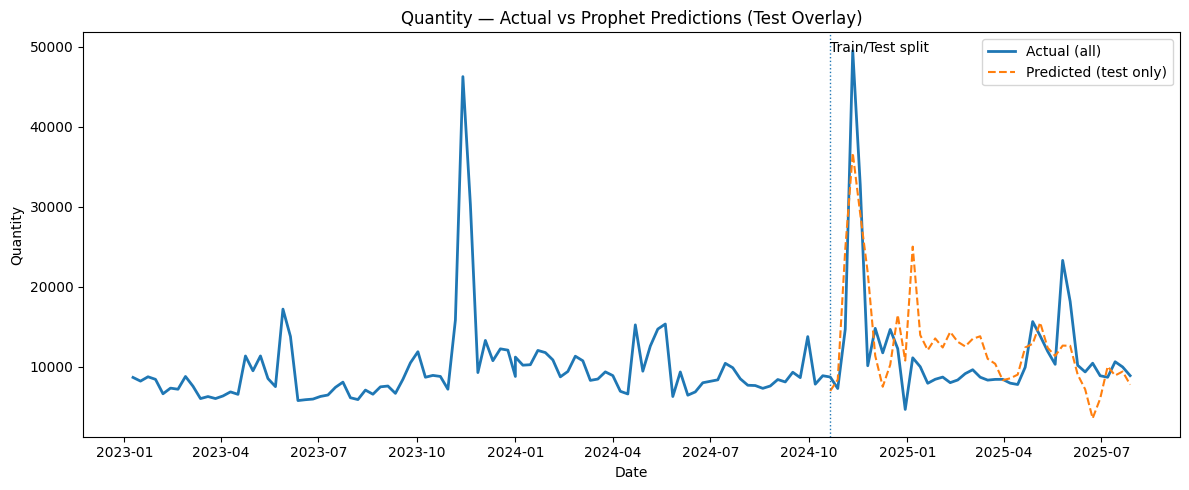

In [65]:
#Build a frame with actuals for the whole period and predictions only for test dates
plot_df = df_work[['ds','y']].merge(
    pred_test[['ds','yhat']], on='ds', how='left'
).sort_values('ds')

split_date = test_df['ds'].min()

plt.figure(figsize=(12, 5))
plt.plot(plot_df['ds'], plot_df['y'], label='Actual (all)', linewidth=2)
plt.plot(plot_df['ds'], plot_df['yhat'], label='Predicted (test only)', linestyle='--')

# Vertical line at the train/test split
plt.axvline(split_date, linestyle=':', linewidth=1)
plt.text(split_date, plt.ylim()[1]*0.98, 'Train/Test split', va='top', ha='left')

plt.title('Quantity — Actual vs Prophet Predictions (Test Overlay)')
plt.xlabel('Date'); plt.ylabel('Quantity')
plt.legend()
plt.tight_layout()
plt.show()


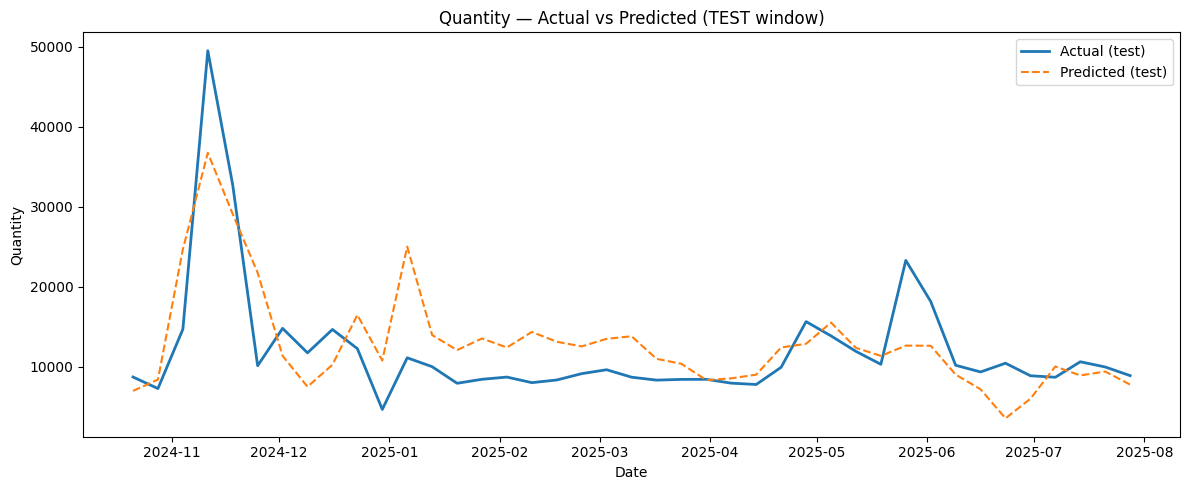

In [66]:
test_plot = plot_df[plot_df['ds'].between(test_df['ds'].min(), test_df['ds'].max())]

plt.figure(figsize=(12, 5))
plt.plot(test_plot['ds'], test_plot['y'], label='Actual (test)', linewidth=2)
plt.plot(test_plot['ds'], test_plot['yhat'], label='Predicted (test)', linestyle='--')

plt.title('Quantity — Actual vs Predicted (TEST window)')
plt.xlabel('Date'); plt.ylabel('Quantity')
plt.legend()
plt.tight_layout()
plt.show()

# elasticity model

elasticity for each segment

In [67]:
df_merged

,WEEK,MONTH,YEAR,segment,unit_price,total_cost,quantity,avg_inventory_whp,DCM,DCM_margin,competitor_price,qty_last_week,price_last_week,comp_last_week,qty_avg_prev_4w
0,1,1,2023,FRONT LOAD,12164.374177,8543.459091,557.0,9.015177,3620.915086,0.291120,25295.037886,NaN,NaN,NaN,NaN
1,1,1,2023,LAUNDRY CENTER,21050.511291,16747.506370,77.0,8.466667,4303.004921,0.193320,39408.939867,NaN,NaN,NaN,814.75
2,1,1,2023,SINGLE TUB,4181.653138,2280.509047,1457.0,9.291667,1901.144091,0.453878,4841.715583,NaN,NaN,NaN,136.00
3,1,1,2023,TOP LOAD,10887.995154,7176.262865,7936.0,38.999939,3711.732289,0.329450,17460.092096,NaN,NaN,NaN,1888.50
4,1,1,2023,TWIN TUB,5437.338830,3362.288857,374.0,22.244048,2075.049972,0.367367,8075.528579,NaN,NaN,NaN,9045.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,52,12,2024,LAUNDRY CENTER,18667.416293,13985.193979,249.0,0.000000,4682.222314,0.213412,37206.150942,83.0,19848.139402,37019.999811,88.00
811,52,12,2024,SINGLE TUB,4216.013893,2186.431436,1532.0,0.165738,2029.582456,0.484277,5025.040044,2134.0,4095.997803,4961.054551,1827.50
812,52,12,2024,TOP LOAD,10243.892923,6138.249280,8715.0,0.394469,4105.643643,0.398513,18555.502141,8410.0,10276.792935,19535.210044,9013.75
813,52,12,2024,TWIN TUB,5205.734119,2886.008363,934.0,0.054762,2319.725756,0.436693,7758.918915,635.0,5386.322098,7629.676731,877.50


In [68]:
# Current-period logs
df_merged['ln_qty']   = np.log(df_merged['quantity'])
df_merged['ln_price'] = np.log(df_merged['unit_price'])
df_merged['ln_cost']  = np.log(df_merged['total_cost'])
df_merged['ln_competitor_price'] = np.log(df_merged['competitor_price'])

C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


elasticity adding competitors prices

# CHOSEN ONE FOR PRICE

In [ ]:
import statsmodels.formula.api as smf
results = []

for seg, data in df_merged.groupby('segment'):
    #drop missing values
    data = data.dropna(subset=['ln_qty', 'ln_price', 'ln_competitor_price', 'ln_cost'])
    if len(data) < 30:
        continue

    model = smf.ols('ln_qty ~ ln_price + ln_competitor_price', data=data).fit()
    own_elast = model.params['ln_price']
    cross_elast = model.params['ln_competitor_price']

    #average cost and current price
    avg_cost = np.exp(data['ln_cost']).mean()
    avg_price = np.exp(data['ln_price']).mean()

    #optimum price based on elasticity
    p_opt = avg_cost * (own_elast / (own_elast + 1))
    
    #metrics
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    results.append({
        'segment': seg,
        'own_elasticity': own_elast,
        'cross_elasticity': cross_elast,
        'avg_cost': avg_cost,
        'avg_price': avg_price,
        'opt_price': p_opt,
        'r2': model.rsquared,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE_%': mape
    })

opt_results = pd.DataFrame(results)
display(opt_results)
